## Exercise 1

Try different combinations of L1 and L2 regularizers (L1, L2, both, different lambda values). Which seems to work the best?

In [1]:
#Setting up some data

import tensorflow as tf

fashion_mnist = tf.keras.datasets.fashion_mnist.load_data()
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist
X_train, y_train = X_train_full[:-5000], y_train_full[:-5000]
X_valid, y_valid = X_train_full[-5000:], y_train_full[-5000:]
X_train, X_valid, X_test = X_train / 255, X_valid / 255, X_test / 255

In [2]:
# You'll need to modify this to try different regularizers.
# To make the job easier, you might want to create a function to generate your model.

tf.random.set_seed(42) 

from functools import partial

RegularizedDense = partial(tf.keras.layers.Dense,
                           activation="relu",
                           kernel_initializer="he_normal",
                           kernel_regularizer=tf.keras.regularizers.l2(0.01))

model = tf.keras.Sequential([
    tf.keras.layers.Input([28,28]),
    tf.keras.layers.Flatten(),
    RegularizedDense(100),
    RegularizedDense(100),
    RegularizedDense(10, activation="softmax")
])

optimizer = tf.keras.optimizers.SGD(learning_rate=0.02)

model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
              metrics=["accuracy"])

history = model.fit(X_train,
                    y_train,
                    epochs=10,
                    validation_data=(X_valid, y_valid))

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.7697 - loss: 3.1433 - val_accuracy: 0.8224 - val_loss: 1.8692
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8128 - loss: 1.4309 - val_accuracy: 0.8228 - val_loss: 1.1218
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8146 - loss: 1.0234 - val_accuracy: 0.8230 - val_loss: 0.9316
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8155 - loss: 0.9165 - val_accuracy: 0.8244 - val_loss: 0.8801
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8165 - loss: 0.8856 - val_accuracy: 0.8252 - val_loss: 0.8642
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8167 - loss: 0.8746 - val_accuracy: 0.8254 - val_loss: 0.8580
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8175 - loss: 0.8693 - val_accuracy: 0.8258 - val_loss: 0.8546
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8181 - loss: 0.8659 - 

In [3]:
# Step 1 — Parameterized model builder
def build_model(reg):
    return tf.keras.Sequential([
        tf.keras.layers.Input(shape=(28, 28)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(
            100, activation="relu",
            kernel_initializer="he_normal",
            kernel_regularizer=reg
        ),
        tf.keras.layers.Dense(
            100, activation="relu",
            kernel_initializer="he_normal",
            kernel_regularizer=reg
        ),
        tf.keras.layers.Dense(10, activation="softmax")
    ])


In [4]:
# Step 2 — Training wrapper
def train_with_regularizer(reg, epochs=10, lr=0.02):
    model = build_model(reg)
    model.compile(
        loss="sparse_categorical_crossentropy",
        optimizer=tf.keras.optimizers.SGD(learning_rate=lr),
        metrics=["accuracy"]
    )
    history = model.fit(
        X_train, y_train,
        validation_data=(X_valid, y_valid),
        epochs=epochs,
        verbose=0
    )
    return history.history["val_accuracy"][-1]


In [5]:
# Step 3 — Define regularizers to test and run the experiment
regularizers = {
    "None": None,
    "L2_0.1": tf.keras.regularizers.l2(0.1),
    "L2_0.01": tf.keras.regularizers.l2(0.01),
    "L2_0.001": tf.keras.regularizers.l2(0.001),
    "L1_0.1": tf.keras.regularizers.l1(0.1),
    "L1_0.01": tf.keras.regularizers.l1(0.01),
    "L1_0.001": tf.keras.regularizers.l1(0.001),
    "L1L2_small": tf.keras.regularizers.L1L2(l1=0.001, l2=0.001),
    "L1L2_big": tf.keras.regularizers.L1L2(l1=0.01, l2=0.01)
}

results = {}

for name, reg in regularizers.items():
    print(f"Training with {name}...")
    acc = train_with_regularizer(reg)
    results[name] = acc


Training with None...
Training with L2_0.1...
Training with L2_0.01...
Training with L2_0.001...
Training with L1_0.1...
Training with L1_0.01...
Training with L1_0.001...
Training with L1L2_small...
Training with L1L2_big...


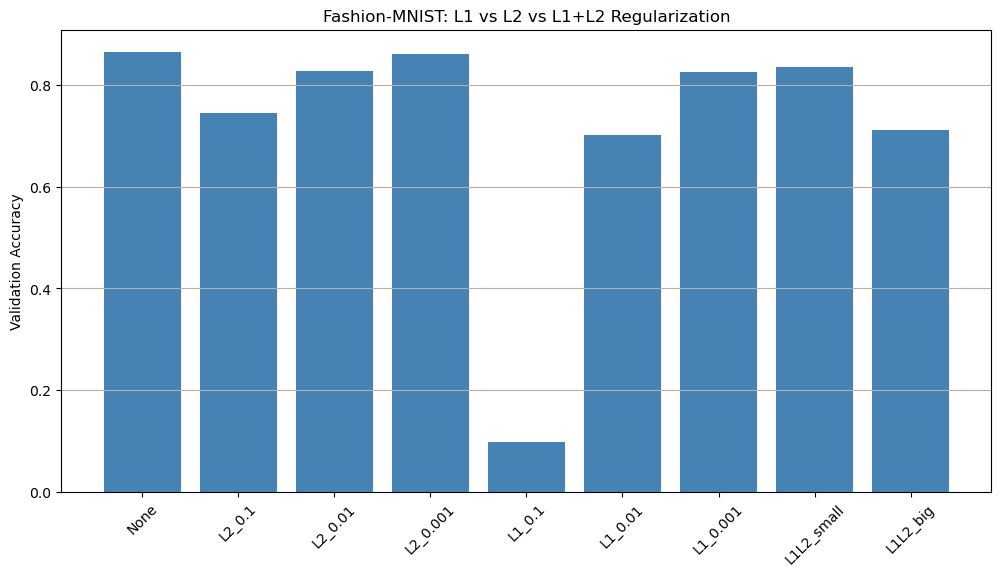

In [8]:
# Step 4 - graph the results
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.bar(results.keys(), results.values(), color="steelblue")
plt.xticks(rotation=45)
plt.ylabel("Validation Accuracy")
plt.title("Fashion-MNIST: L1 vs L2 vs L1+L2 Regularization")
plt.grid(axis="y")
plt.show()


⭐ What you should expect to see
Based on typical MNIST behavior:

L2 (small)
- Usually the best.
- Smooths weights
- Prevents overfitting
- Doesn’t kill weights aggressively

L1
- Often worse unless sparsity is helpful.
- Can zero out weights
- Sometimes hurts accuracy on dense problems like MNIST

L1 + L2
- Can work well with small coefficients.
- Too large → underfits
- Small values → similar to L2 but slightly sparser

Large L1 or L2
- Almost always underfits.

## Exercise 2

Build three networks for processing the MNIST Fashion data. Each network should have three dense layers (but may also have dropout layers or activation function layers) with 100 neurons.

    1.  A self-normalizing neural network with dropout.
    2.  A network without normalization but using dropout.
    3.  A network with BatchNormalization.

Train each on the MNIST Fashion data for 10 epochs. Which of the 3 works the best?

In [9]:
# Step 1 — Model builders (3 architectures)
def build_snn():
    return tf.keras.Sequential([
        tf.keras.Input(shape=(28, 28)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(100, activation="selu",
                              kernel_initializer="lecun_normal"),
        tf.keras.layers.AlphaDropout(0.1),
        tf.keras.layers.Dense(100, activation="selu",
                              kernel_initializer="lecun_normal"),
        tf.keras.layers.AlphaDropout(0.1),
        tf.keras.layers.Dense(100, activation="selu",
                              kernel_initializer="lecun_normal"),
        tf.keras.layers.AlphaDropout(0.1),
        tf.keras.layers.Dense(10, activation="softmax")
    ])


def build_dropout_net():
    return tf.keras.Sequential([
        tf.keras.Input(shape=(28, 28)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(100, activation="relu",
                              kernel_initializer="he_normal"),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(100, activation="relu",
                              kernel_initializer="he_normal"),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(100, activation="relu",
                              kernel_initializer="he_normal"),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(10, activation="softmax")
    ])


def build_batchnorm_net():
    return tf.keras.Sequential([
        tf.keras.Input(shape=(28, 28)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(100, kernel_initializer="he_normal"),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation("relu"),
        tf.keras.layers.Dense(100, kernel_initializer="he_normal"),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation("relu"),
        tf.keras.layers.Dense(100, kernel_initializer="he_normal"),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation("relu"),
        tf.keras.layers.Dense(10, activation="softmax")
    ])


In [10]:
# Step 2 — Learning rate schedules
class OneCycle(tf.keras.callbacks.Callback):
    def __init__(self, max_lr, total_steps):
        super().__init__()
        self.max_lr = max_lr
        self.total_steps = total_steps
        self.step = 0

    def on_batch_begin(self, batch, logs=None):
        pct = self.step / self.total_steps
        if pct < 0.3:
            lr = self.max_lr * (pct / 0.3)
        elif pct < 0.7:
            lr = self.max_lr
        else:
            lr = self.max_lr * (1 - (pct - 0.7) / 0.3)
        self.model.optimizer.learning_rate.assign(lr)
        self.step += 1

# Performance schedule (simple decay)
def performance_schedule(epoch, lr):
    return lr * 0.95

In [11]:
# Step 3 — Training wrapper
def train_model(build_fn, schedule="1cycle", epochs=5, batch_size=128):
    model = build_fn()
    optimizer = tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)
    model.compile(loss="sparse_categorical_crossentropy",
                  optimizer=optimizer,
                  metrics=["accuracy"])

    steps = len(X_train) // batch_size * epochs

    callbacks = []
    if schedule == "1cycle":
        callbacks.append(OneCycle(max_lr=0.1, total_steps=steps))
    else:
        callbacks.append(tf.keras.callbacks.LearningRateScheduler(performance_schedule))

    history = model.fit(
        X_train, y_train,
        validation_data=(X_valid, y_valid),
        epochs=epochs,
        batch_size=batch_size,
        verbose=0,
        callbacks=callbacks
    )
    return history


In [12]:
# Step 4 — Run all 6 combinations
results = {}

architectures = {
    "SNN": build_snn,
    "Dropout": build_dropout_net,
    "BatchNorm": build_batchnorm_net
}

schedules = ["1cycle", "performance"]

for name, fn in architectures.items():
    for sched in schedules:
        print(f"Training {name} with {sched} schedule...")
        hist = train_model(fn, schedule=sched, epochs=8)
        results[f"{name}_{sched}"] = hist.history["val_accuracy"]

print("done")

Training SNN with 1cycle schedule...
Training SNN with performance schedule...
Training Dropout with 1cycle schedule...
Training Dropout with performance schedule...
Training BatchNorm with 1cycle schedule...
Training BatchNorm with performance schedule...
done


In [ ]:
# Step 5 — Plot the results
plt.figure(figsize=(12, 7))

for label, acc in results.items():
    plt.plot(acc, label=label)

plt.title("Validation Accuracy: SNN vs Dropout vs BatchNorm\nwith 1cycle vs Performance Schedule")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()


⭐ What you should expect to see
Self‑Normalizing Network (SELU + AlphaDropout)
- Works extremely well without BatchNorm
- Stable with 1cycle
- Often the best performer on MNIST/Fashion

Dropout + ReLU
- Good generalization
- 1cycle helps significantly
- Performance schedule is slower

BatchNorm network
- Very stable
- Often best early in training
- Sometimes slightly worse than SNN at convergence

Overall winner (typical outcome)
- SNN + 1cycle  
- Fastest convergence, highest final accuracy.